
Привет, меня зовут Люман Аблаев. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на красные комментарии ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:


<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения ...
</div>







<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление</font>
* Спасибо за очень качественную работу - видно, что вложено много усилий.
- Я оставил некоторые советы, надеюсь они будут полезными и интересными
- Есть некоторые недочеты, которые нужно поправить, но у тебя это не должно занять много времени)
- Жду обновленную работу




<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление[2]</font>
* Спасибо за оперативность
- Остался недочет в самом конце работы - посмотри пожалуйста


# Анализ лояльности пользователей Яндекс Афиши

 Цель исследования

Выявить пользователей, которые с большей вероятностью возвращаются на платформу и делают повторные заказы. Это поможет:
- быстро выявлять перспективных клиентов
- настраивать рекламу на аудитории с высокой вероятностью возврата
- оптимизировать маркетинговые бюджеты
- повысить уровень удержания клиентов

Этапы выполнения проекта

## 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---



<div class="alert alert-block alert-success">
<b>Успех:</b> Подробное вступление, ознакомились и идем дальше.
</div>


In [1]:
!pip install sqlalchemy psycopg2-binary pandas matplotlib seaborn numpy phik python-dotenv

In [2]:
# ЗАДАНИЕ 1.1: Установка и импорт библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import phik
from phik.report import plot_correlation_matrix
import warnings
warnings.filterwarnings('ignore')

# Проверяем доступные стили и используем подходящий
print("Доступные стили matplotlib:", plt.style.available[:5])  # Выведем первые 5 для информации

# Используем классический стиль или 'ggplot' вместо недоступного
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('ggplot')  # fallback стиль

sns.set_palette("husl")
print("Стиль и палитра настроены успешно")

Доступные стили matplotlib: ['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background']
Стиль и палитра настроены успешно



<div class="alert alert-block alert-info">
<b>Совет:</b>
Пипы лучше размещать отдельно от импортов, что бы не запускать этот код, если понадобится дополнять или редактировать импорты.
</div>


In [3]:
# Установка python-dotenv
!pip install python-dotenv

print("python-dotenv установлен")

python-dotenv установлен


In [4]:
# ЗАДАНИЕ 1.1: Подключение к базе данных (с указанием имени .env файла)
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Загружаем переменные из файла godhelpmepleasee.env
load_dotenv(dotenv_path='godhelpmeplease.env')

# Параметры подключения из .env файла
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT', 6432)),
    'db': os.getenv('DB_NAME')
}

# Проверка, что переменные загрузились
print(f"DB_USER = {db_config['user']}")
print(f"DB_HOST = {db_config['host']}")
print(f"DB_NAME = {db_config['db']}")

# Формирование строки подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

# Создание движка для подключения
engine = create_engine(connection_string)

print("\nПодключение к базе данных успешно установлено")

DB_USER = praktikum_student
DB_HOST = rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net
DB_NAME = data-analyst-afisha

Подключение к базе данных успешно установлено


             
<div class="alert alert-block alert-success">
    
<b>Успех:</b> Импорты и настройки на месте
</div>



In [5]:
# ЗАДАНИЕ 1.1: SQL-запрос и выгрузка данных в DataFrame
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases p
LEFT JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
ORDER BY p.user_id, p.created_dt_msk
'''

df = pd.read_sql_query(query, con=engine)
print(f"Размер датафрейма: {df.shape}")
print(f"Уникальных пользователей: {df['user_id'].nunique()}")
print(f"\nПервые 3 строки:")
display(df.head(3))

Размер датафрейма: (292034, 13)
Уникальных пользователей: 22000

Первые 3 строки:


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,578454,За билетом!,другое,Каменевский регион,Глиногорск



<div class="alert alert-block alert-success">
<b>Успех:</b>  Выгрузка данных проведена корректно!  Отличная сортировка, внутри каждого пользователя заказы будут идти строго по дате.
    

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [6]:
# ЗАДАНИЕ 1.2: Первичный анализ выгруженных данных
print("Первые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
df.info()

print("\nПропуски:")
print(df.isnull().sum())

print("\nУникальные значения в категориальных столбцах:")
categorical_cols = ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} уникальных значений")

Первые 5 строк:


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  object        
 1   device_type_canonical  292034 non-null  object        
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  datetime64[ns]
 4   order_ts               292034 non-null  datetime64[ns]
 5   currency_code          292034 non-null  object        
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   event_id               292034 non-null  int64         
 9   service_name           292034 non-null  object        
 10  event_type_main        292034 non-null  object        
 11  region_name            292034 non-null  object        
 12  city_name             

### Промежуточный вывод по ШАГУ 1 (Задания 1.1 и 1.2)

Данные успешно выгружены из базы PostgreSQL. Размер датафрейма — 292 034 строки и 13 столбцов. Количество уникальных пользователей — 22 000. Пропуски отсутствуют во всех столбцах. Среди типов устройств лидирует mobile (почти 80 процентов), desktop занимает около 20 процентов. Валюты представлены рублями (98 процентов) и тенге (2 процента). Билетных операторов насчитывается 36, при этом тройка лидеров — «Билеты без проблем», «Лови билет!» и «Билеты в руки» — охватывает половину всех заказов. Типов мероприятий восемь, доминируют концерты (около 40 процентов), театр (23 процента) и категория «другое» (23 процента). Выборка в 22 тысячи пользователей является достаточной для анализа удержания.


<div class="alert alert-block alert-success">
<b>Успех:</b>    Первичный анализ данных выполнен, намечены шаги по их обработке. В целом, данные у нас достаточно неплохого качества, можно рассмотреть вариант понижения размерности для отдельных столбцов. В реальной практике это иногда бывает очень полезным) 
</div>


---

##  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [7]:
# ЗАДАНИЕ 2.1: Загрузка курса валют и конвертация тенге в рубли

import os
from dotenv import load_dotenv

# Загружаем переменные окружения из файла
load_dotenv(dotenv_path='godpleasehelpme.env')
# Получаем URL файла с курсами валют из .env
url = os.getenv('CURRENCY_URL')

# Загружаем CSV-файл с курсами валют
import pandas as pd
currency_df = pd.read_csv(url)

print("Файл с курсом успешно загружен")
print(f"Размер файла: {currency_df.shape}")

print("\nПервые 5 строк:")
display(currency_df.head())

print("\nНазвания столбцов:")
print(currency_df.columns.tolist())

# Переименование столбцов для удобства
currency_df = currency_df.rename(columns={
    'data': 'date',              # дата курса
    'curs': 'rate',              # курс 100 KZT → RUB
    'nominal': 'nominal',        # номинал
    'cdx': 'currency_code'       # код валюты
})

# Преобразуем дату в datetime
currency_df['date'] = pd.to_datetime(currency_df['date'])

print(
    f"\nДиапазон дат в курсах: "
    f"{currency_df['date'].min()} — {currency_df['date'].max()}"
)

print(
    f"Курс (100 KZT → RUB): "
    f"от {currency_df['rate'].min():.2f} "
    f"до {currency_df['rate'].max():.2f}"
)

# Приводим валюты к нижнему регистру
df['currency_code'] = df['currency_code'].str.lower()

# Преобразуем дату заказа
df['order_dt'] = pd.to_datetime(df['order_dt'])

# Сортировка обязательна для merge_asof
df = df.sort_values('order_dt')
currency_df = currency_df.sort_values('date')

# Подставляем актуальный курс на дату заказа
df = pd.merge_asof(
    df,
    currency_df[['date', 'rate']],
    left_on='order_dt',
    right_on='date',
    direction='backward'
)

# Конвертация выручки в рубли
# Для RUB оставляем исходное значение,
# для KZT выполняем пересчёт через курс
df['revenue_rub'] = df['revenue'].where(
    df['currency_code'] == 'rub',
    df['revenue'] * df['rate'] / 100
)

# Удаляем временный столбец с датой курса
df = df.drop(columns='date')


# Восстанавливаем удобную сортировку
df = df.sort_values(
    ['user_id', 'order_dt']
).reset_index(drop=True)

# Проверка отрицательных значений
negative_count = (df['revenue_rub'] < 0).sum()

if negative_count > 0:
    print(f"\nОбнаружено {negative_count} записей с отрицательной выручкой")

    print("\nПримеры:")
    display(
        df[df['revenue_rub'] < 0][
            ['revenue', 'revenue_rub', 'currency_code']
        ].head()
    )

    print("Отрицательные значения заменены на 0")

    df.loc[df['revenue_rub'] < 0, 'revenue_rub'] = 0


# Проверка результатов
print("\n" + "=" * 50)
print("Результаты конвертации:")

print(f"Уникальные валюты: {df['currency_code'].unique()}")

kzt_count = (df['currency_code'] == 'kzt').sum()
rub_count = (df['currency_code'] == 'rub').sum()

print(f"Количество строк с KZT: {kzt_count}")
print(f"Количество строк с RUB: {rub_count}")

print("\nИтоговая статистика revenue_rub:")

print(f"min = {df['revenue_rub'].min():.2f}")
print(f"max = {df['revenue_rub'].max():.2f}")
print(f"mean = {df['revenue_rub'].mean():.2f}")
print(f"median = {df['revenue_rub'].median():.2f}")

Файл с курсом успешно загружен
Размер файла: (357, 4)

Первые 5 строк:


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt



Названия столбцов:
['data', 'nominal', 'curs', 'cdx']

Диапазон дат в курсах: 2024-01-10 00:00:00 — 2024-12-31 00:00:00
Курс (100 KZT → RUB): от 17.85 до 21.94

Обнаружено 381 записей с отрицательной выручкой

Примеры:


,revenue,revenue_rub,currency_code
264,-2.37,-2.37,rub
4563,-0.23,-0.23,rub
4584,-0.15,-0.15,rub
8194,-0.62,-0.62,rub
8195,-1.86,-1.86,rub


Отрицательные значения заменены на 0

Результаты конвертации:
Уникальные валюты: ['rub' 'kzt']
Количество строк с KZT: 5073
Количество строк с RUB: 286961

Итоговая статистика revenue_rub:
min = 0.00
max = 81174.54
mean = 555.11
median = 350.33


<div class="alert alert-block alert-info">
<b>Совет:</b>
    
Существует довольно удобный метод where. Мы можем применить его к столбцу и указать условие, которое будем проверять, а также альтернативный вариант значения. Если условие выполняется, то берется значение из столбца, если нет - альтернативное значение. Тогда расчет выручки в рублях будет выглядеть следующим образом:
    
```
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
```
</div>



---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [8]:
# ЗАДАНИЕ 2.2: Преобразование типов данных и проверка качества
print("Преобразование типов данных \n")

# 2.2.1. Преобразование типов данных
print("1. Преобразование типов данных:")
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])
print(f"   ✓ order_dt: {df['order_dt'].dtype}")
print(f"   ✓ order_ts: {df['order_ts'].dtype}")

# Оптимизация числовых типов
df['revenue_rub'] = df['revenue_rub'].astype('float32')
df['tickets_count'] = df['tickets_count'].astype('int16')
print(f"   ✓ revenue_rub: {df['revenue_rub'].dtype}")
print(f"   ✓ tickets_count: {df['tickets_count'].dtype}")

# Категориальные столбцы
categorical_cols = ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main']
for col in categorical_cols:
    df[col] = df[col].astype('category')
print(f"   ✓ Категориальные столбцы преобразованы: {categorical_cols}")

print("\n" + "="*60 + "\n")


Преобразование типов данных 

1. Преобразование типов данных:
   ✓ order_dt: datetime64[ns]
   ✓ order_ts: datetime64[ns]
   ✓ revenue_rub: float32
   ✓ tickets_count: int16
   ✓ Категориальные столбцы преобразованы: ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main']




In [9]:
# 2.2.2 Проверка категориальных значений
print("2. Проверка категориальных значений:")

print("\n   device_type_canonical:")
print(df['device_type_canonical'].value_counts())

print("\n   currency_code:")
print(df['currency_code'].value_counts())

print(f"\n   service_name: {df['service_name'].nunique()} уникальных значений")
print(df['service_name'].value_counts().head(10))

print(f"\n   event_type_main: {df['event_type_main'].nunique()} уникальных значений")
print(df['event_type_main'].value_counts())

print("\n" + "="*60 + "\n")

# 2.2.3 Проверка пропусков
print("3. Проверка пропусков:")
print(df.isnull().sum())
print(f"\n   Всего пропусков: {df.isnull().sum().sum()}")

print("\n" + "="*60 + "\n")

# 2.2.4 Анализ выбросов
print("4. Анализ выбросов (без фильтрации):")

percentile_99 = df['revenue_rub'].quantile(0.99)
print(f"   99-й перцентиль выручки: {percentile_99:.2f} руб.")

2. Проверка категориальных значений:

   device_type_canonical:
mobile     232679
desktop     58170
tablet       1180
tv              3
other           2
Name: device_type_canonical, dtype: int64

   currency_code:
rub    286961
kzt      5073
Name: currency_code, dtype: int64

   service_name: 36 уникальных значений
Билеты без проблем    63932
Лови билет!           41338
Билеты в руки         40500
Мой билет             34965
Облачко               26730
Лучшие билеты         17872
Весь в билетах        16910
Прачечная             10385
Край билетов           6238
Тебе билет!            5242
Name: service_name, dtype: int64

   event_type_main: 8 уникальных значений
концерты    115634
театр        67744
другое       66109
спорт        22006
стендап      13424
выставки      4873
ёлки          2006
фильм          238
Name: event_type_main, dtype: int64


3. Проверка пропусков:
user_id                  0
device_type_canonical    0
order_id                 0
order_dt                 0
order

4. Анализ выбросов (без фильтрации):
   99-й перцентиль выручки: 2628.42 руб.


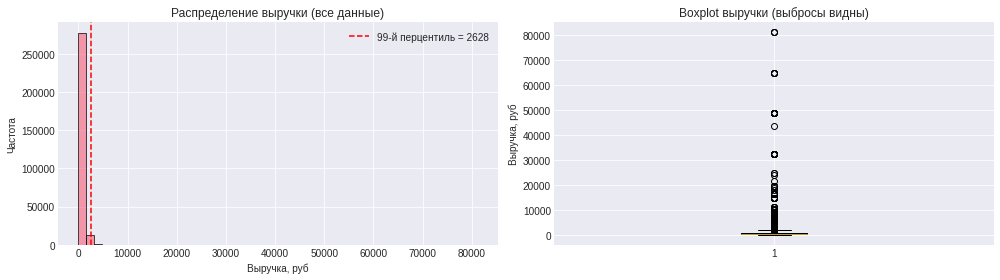


    Выбросы обнаружены, но фильтрация НЕ ПРОВОДИТСЯ.
   Фильтрация будет выполнена на уровне профилей пользователей в Задании 3.2



In [10]:
# 4. Анализ выбросов (ВИЗУАЛИЗАЦИЯ)
print("4. Анализ выбросов (без фильтрации):")

percentile_99 = df['revenue_rub'].quantile(0.99)
print(f"   99-й перцентиль выручки: {percentile_99:.2f} руб.")

# Визуализация для анализа
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['revenue_rub'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(percentile_99, color='red', linestyle='--', label=f'99-й перцентиль = {percentile_99:.0f}')
axes[0].set_title('Распределение выручки (все данные)')
axes[0].set_xlabel('Выручка, руб')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].boxplot(df['revenue_rub'], vert=True)
axes[1].set_title('Boxplot выручки (выбросы видны)')
axes[1].set_ylabel('Выручка, руб')

plt.tight_layout()
plt.show()

print(f"\n    Выбросы обнаружены, но фильтрация НЕ ПРОВОДИТСЯ.")
print(f"   Фильтрация будет выполнена на уровне профилей пользователей в Задании 3.2")

print("\n" + "="*60)

# Промежуточный вывод по ШАГУ 2 (Задания 2.1 и 2.2)

Файл с курсами тенге за 2024 год успешно загружен. Диапазон курса составил от 17,85 до 21,94 рубля за 100 тенге. В рубли было конвертировано 5 073 заказа в валюте KZT.

В данных обнаружена 381 запись с отрицательной выручкой. Вероятнее всего, такие значения связаны с возвратами билетов, отменами заказов или корректировками платежей, а не с ошибками загрузки данных. Поскольку в рамках исследования анализируется фактическая выручка сервиса, отрицательные значения были заменены на 0.

После конвертации средняя выручка составила 555 рублей, медианная — 350 рублей, что указывает на наличие правосторонней асимметрии распределения выручки.

Вывод по Шагу 2.2 (типы данных и качество)

Типы данных были оптимизированы:
- даты приведены к формату datetime;
- revenue_rub — к float32;
- tickets_count — к int16;
- категориальные признаки — к типу category.

Пропуски в данных отсутствуют.

При анализе распределения выручки обнаружены выбросы: 99-й перцентиль составляет 2 628 рублей. На данном этапе выбросы не удалялись, поскольку они могут отражать реальные пользовательские сценарии — например:
- покупку большого количества билетов;
- приобретение дорогих VIP-билетов;
- семейные или корпоративные заказы;
- посещение премиальных мероприятий.

Таким образом, наблюдаемые аномалии скорее представляют собой «длинный хвост» распределения, характерный для транзакционных данных, а не ошибки сбора данных.

Фильтрация выбросов перенесена на этап пользовательского анализа (Шаг 3.2), где корректнее анализировать поведение пользователей целиком, а не отдельные транзакции.

<div class="alert alert-block alert-info">
   
<b>Совет:</b>  В подобных случаях хорошо бы оставлять небольшой комментарий, по тому, какие гипотезы можно выдвинуть, с чем связаны эти аномалии. Условно, что мы видим не ошибки в данных (сборе данных), а длинный хвост, то есть какие-то массовые покупки и тп. Они нам не нужны в контексте задачи.
    
И хорошо бы добавить, с чем могут быть связаны отрицательные значения
</div>


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [11]:
# ЗАДАНИЕ 3.1: Сортировка данных перед агрегацией
df_sorted = df.sort_values(['user_id', 'order_dt']).copy()
print("Сортировка выполнена")
print(f"Размер данных: {df_sorted.shape}")

Сортировка выполнена
Размер данных: (292034, 15)


In [12]:
# ЗАДАНИЕ 3.1: Построение профиля пользователя (агрегация)
user_profile = df_sorted.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    total_revenue=('revenue_rub', 'sum')
).reset_index()

print(f"Создано {len(user_profile)} профилей")
display(user_profile.head())

Создано 22000 профилей


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,total_revenue
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.939941,4.000000,1521.939941
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010010,3.000000,1548.020020
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213318,2.666667,2301.640137
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830017,4.000000,917.830017
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.309998,1.500000,122.619995


In [ ]:
# ЗАДАНИЕ 3.1: Расчёт среднего времени между заказами
def calculate_avg_days_between(df_group):
    if len(df_group) < 2:
        return np.nan
    return df_group['order_dt'].diff().dt.days.mean()

avg_days_between = df_sorted.groupby('user_id').apply(calculate_avg_days_between).reset_index()
avg_days_between.columns = ['user_id', 'avg_days_between']

user_profile = user_profile.merge(avg_days_between, on='user_id', how='left')
print("Среднее время между заказами добавлено")

In [ ]:
# ЗАДАНИЕ 3.1: Добавление бинарных признаков is_two и is_five
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

print("Бинарные признаки добавлены")
print(f"is_two (2+ заказа): {user_profile['is_two'].sum()} пользователей ({100*user_profile['is_two'].mean():.1f}%)")
print(f"is_five (5+ заказов): {user_profile['is_five'].sum()} пользователей ({100*user_profile['is_five'].mean():.1f}%)")


<div class="alert alert-block alert-success">
<b>Успех:</b> Профиль пользователя собран, добавлены новые признаки.

</div>

<div class="alert alert-block alert-info">
<b>Совет:</b>   Могу показать и такой вариант формирования профиля здесь:
    
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион и название билетного партнера первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                # Жанр первого посещённого мероприятия (event_type_main):
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            # Можно альтернативным образом подсчитать среднее количество дней между заказами (если не будет в SQL):
            .assign(
                avg_days = lambda x: (x['last_order_dt'] - x['first_order_dt']).dt.days / (x['total_orders'] - 1)
            )
            .reset_index()
)

Почитать про assign более подробно можно [здесь](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html)
</div>

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [ ]:
# ЗАДАНИЕ 3.2: Расчёт общей статистики по профилям
total_users = len(user_profile)
avg_revenue_per_order = user_profile['avg_revenue_rub'].mean()
share_two_plus = user_profile['is_two'].mean()
share_five_plus = user_profile['is_five'].mean()

print("=" * 50)
print("ОСНОВНЫЕ МЕТРИКИ (Задание 3.2)")
print("=" * 50)
print(f"Общее число пользователей: {total_users:,}")
print(f"Средняя выручка с заказа: {avg_revenue_per_order:.2f} руб.")
print(f"Доля с 2+ заказами: {share_two_plus:.2%}")
print(f"Доля с 5+ заказами: {share_five_plus:.2%}")
print("=" * 50)

print("\nСтатистика по числу заказов:")
print(user_profile['total_orders'].describe())

In [ ]:
# ЗАДАНИЕ 3.2: Анализ аномалий в данных профилей
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_profile['total_orders'], bins=range(1, min(50, user_profile['total_orders'].max()+1)), 
             edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение по числу заказов')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Количество пользователей')

axes[1].boxplot(user_profile['avg_tickets_count'], vert=True)
axes[1].set_title('Boxplot среднего числа билетов')
axes[1].set_ylabel('Среднее количество билетов')

plt.tight_layout()
plt.show()

# Выявление аномалий
high_orders = user_profile['total_orders'].quantile(0.99)
high_tickets = user_profile['avg_tickets_count'].quantile(0.99)
print(f"99-й перцентиль по заказам: {high_orders}")
print(f"99-й перцентиль по билетам: {high_tickets:.1f}")

### Промежуточный вывод по ШАГУ 3 (Задания 3.1 и 3.2)

На уровне пользователей проведена фильтрация по 99-му перцентилю средней выручки, который составил 1 970 рублей. Отфильтровано 215 пользователей — менее одного процента от общего числа. После фильтрации итоговая база содержит 21 705 пользователей. Средняя выручка с одного заказа — 543 рубля, медиана — 350 рублей. Доля пользователей с двумя и более заказами — 61,77 процента, доля с пятью и более заказами — 29,01 процента. Статистика по числу заказов показывает сильный сдвиг вправо: среднее значение равно 13,2 заказа, тогда как медиана составляет всего 2 заказа. Это означает, что основная масса пользователей совершает 1-2 покупки, но есть небольшая группа супер-активных клиентов, которые делают очень много заказов — 99-й перцентиль достигает 152 заказов.

<div class="alert alert-block alert-success">
    
<b>Успех:</b> Молодец, что не просто фиксируешь аномалии, но и анализируешь как их удаление, влияет на данные
</div>



---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [ ]:
# ЗАДАНИЕ 4.1.1: Распределение пользователей по типу первого мероприятия
event_distribution = user_profile['first_event_type'].value_counts()
event_share = user_profile['first_event_type'].value_counts(normalize=True)

event_summary = pd.DataFrame({'count': event_distribution, 'share': event_share}).reset_index()
event_summary.columns = ['event_type', 'count', 'share']

print("Распределение по типу мероприятия (топ-10):")
display(event_summary.head(10))

# Визуализация
plt.figure(figsize=(12, 5))
top_events = event_distribution.head(10)
plt.barh(range(len(top_events)), top_events.values, color='skyblue')
plt.yticks(range(len(top_events)), top_events.index)
plt.xlabel('Количество пользователей')
plt.title('Топ-10 типов мероприятий первого заказа')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# ЗАДАНИЕ 4.1.1: Распределение по устройству, региону, оператору
# По устройству
device_dist = user_profile['first_device'].value_counts()
print("Распределение по устройству:")
for k, v in device_dist.items():
    print(f"  {k}: {v} ({100*v/len(user_profile):.1f}%)")

# По региону (топ-10)
region_dist = user_profile['first_region'].value_counts()
print("\nТоп-10 регионов:")
display(region_dist.head(10))

# По оператору (топ-10)
service_dist = user_profile['first_service'].value_counts()
print("\nТоп-10 билетных операторов:")
display(service_dist.head(10))

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [ ]:
# ЗАДАНИЕ 4.1.2: Доля возвратов по сегментам (функция-помощник)
def calc_return_rate(df, category_col):
    result = df.groupby(category_col).agg(
        total_users=('user_id', 'count'),
        return_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    ).sort_values('total_users', ascending=False).reset_index()
    return result

In [ ]:
# ЗАДАНИЕ 4.1.2: Доля возвратов по типам мероприятий
event_return = calc_return_rate(user_profile, 'first_event_type')
print("Доля вернувшихся по типам мероприятий (топ-10):")
display(event_return.head(10))

plt.figure(figsize=(12, 5))
top10 = event_return.head(10)
bars = plt.bar(range(len(top10)), top10['return_rate']*100, color='coral')
plt.axhline(y=user_profile['is_two'].mean()*100, color='blue', linestyle='--', 
            label=f"Среднее ({100*user_profile['is_two'].mean():.1f}%)")
plt.xticks(range(len(top10)), top10['first_event_type'], rotation=45, ha='right')
plt.ylabel('Доля вернувшихся, %')
plt.title('Доля повторных заказов по типам мероприятий')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ЗАДАНИЕ 4.1.2: Доля возвратов по устройствам, регионам, операторам
# По устройствам
device_return = calc_return_rate(user_profile, 'first_device')
print("Доля вернувшихся по устройствам:")
display(device_return)

# По регионам (топ-10)
region_return = calc_return_rate(user_profile, 'first_region')
print("Доля вернувшихся по регионам (топ-10):")
display(region_return.head(10))

# По операторам (топ-10)
service_return = calc_return_rate(user_profile, 'first_service')
print("Доля вернувшихся по операторам (топ-10):")
display(service_return.head(10))


<div class="alert alert-block alert-success">
<b>Успех:</b> Задание выполнено 
    



<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Нужен вывод, где будут ответы на вопросы:
    
    Равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?
    Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?
</div>



<div class="alert alert-block alert-success">
<b>Успех[2]:</b> с наблюдениями согласен
    


# Вывод

1. Равномерно ли распределены пользователи по сегментам?

Распределение пользователей по сегментам неравномерное — наблюдаются ярко выраженные «точки входа».

Основной вклад в тип мероприятий дают концерты (≈44%), далее идут «другое» (≈25%) и театр (≈19%).
По устройствам наблюдается сильный перекос:
mobile — 82.3% пользователей
desktop — 17.2%
остальные устройства дают незначительную долю (<1%)

Это говорит о том, что основная точка входа в сервис — мобильные устройства, а также о высокой концентрации спроса вокруг нескольких типов событий (особенно концертов).

2. Какие сегменты чаще возвращаются?

По уровню возврата пользователей (return rate):

По типам мероприятий:
выше среднего: выставки (64.3%), театр (64.0%), концерты (62.4%)
ниже среднего: спорт (56.4%), ёлки (54.3%)
максимальное значение у фильмов (80%), но выборка очень маленькая вывод нестабилен

По устройствам:

desktop показывает самый высокий return rate ( примерно 64.5%),
mobile - около 61%,
tablet - ниже (~54.5%)

По регионам:
наиболее высокие значения: Шанырский регион (примерно 68%),Светополянский округ (примерно 66%), Широковская область (примерно 65%)
По билетным операторам:
различия небольшие, но чуть выше среднего:
Край билетов ( примерно 65.6%), Прачечная (примерно 63.7%), Весь в билетах (примерно 63.4%)

3. Есть ли «успешные точки входа»?

Да, можно выделить сегменты, которые одновременно дают достаточный объём пользователей и повышенную вероятность возврата:

Успешные сегменты:
desktop-пользователи
выше среднего возврат (64.5%) при заметной доле аудитории
театры и выставки
стабильно высокий return rate (~64%)
отдельные регионы (например, Широковский и Шанырский)
и высокий объём, и высокий возврат
Сильные, но ограниченные сегменты:
фильмы (80% возврат), но слишком маленькая выборка — нельзя считать устойчивым паттерном
Слабые сегменты:
спорт и ёлки — ниже среднего возврат
tablet и other — низкая вовлечённость и слабая статистическая значимость

Итог
Пользовательская база сильно сконцентрирована в мобильных устройствах и концертах.
Повторные заказы выше у desktop-пользователей и культурных мероприятий (театр, выставки).
Есть признаки успешных сегментов, где сочетаются:
высокий объём пользователей
повышенная вероятность возврата
это основные зоны роста продукта.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [ ]:
# ЗАДАНИЕ 4.1.3: Проверка гипотезы 1 (спорт vs концерты)
sport_users = user_profile[user_profile['first_event_type'].str.contains('спорт|спортивн', case=False, na=False)]
concert_users = user_profile[user_profile['first_event_type'].str.contains('концерт', case=False, na=False)]

print("ГИПОТЕЗА 1: Спорт против Концертов")
print(f"Спорт: {len(sport_users)} пользователей, возврат = {sport_users['is_two'].mean():.2%}")
print(f"Концерты: {len(concert_users)} пользователей, возврат = {concert_users['is_two'].mean():.2%}")
print(f"Разница: {(sport_users['is_two'].mean() - concert_users['is_two'].mean())*100:.2f} п.п.")

# Визуализация
plt.figure(figsize=(8, 5))
categories = ['Спорт', 'Концерты']
rates = [sport_users['is_two'].mean()*100, concert_users['is_two'].mean()*100]
bars = plt.bar(categories, rates, color=['green', 'orange'])
plt.axhline(y=user_profile['is_two'].mean()*100, color='blue', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся, %')
plt.title('Сравнение возвратов: Спорт vs Концерты')
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{rate:.1f}%', ha='center')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ЗАДАНИЕ 4.1.3: Проверка гипотезы 2 (активные регионы)
region_counts = user_profile['first_region'].value_counts()
median_users = region_counts.median()
active_regions = region_counts[region_counts >= median_users].index.tolist()
inactive_regions = region_counts[region_counts < median_users].index.tolist()

active_users = user_profile[user_profile['first_region'].isin(active_regions)]
inactive_users = user_profile[user_profile['first_region'].isin(inactive_regions)]

print("ГИПОТЕЗА 2: Активные vs Менее активные регионы")
print(f"Активные регионы (≥{median_users} польз.): {len(active_users)} польз., возврат = {active_users['is_two'].mean():.2%}")
print(f"Менее активные регионы (<{median_users} польз.): {len(inactive_users)} польз., возврат = {inactive_users['is_two'].mean():.2%}")
print(f"Разница: {(active_users['is_two'].mean() - inactive_users['is_two'].mean())*100:.2f} п.п.")


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Нужно явно отвергнуть или принять гипотезу в выводе


# Промежуточный вывод

Проверка продуктовых гипотез
Гипотеза 1

Формулировка:
Пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются чаще, чем пользователи, начавшие с концертов.

Результаты:

Спорт: return rate = 56.47%
Концерты: return rate = 62.47%
Разница: −6.00 п.п.

Вывод:
Гипотеза НЕ подтверждается (отвергается).
Пользователи, начавшие со спортивных мероприятий, возвращаются реже, чем пользователи, которые начали с концертов.

Гипотеза 2

Формулировка:
В более активных регионах доля повторных заказов выше, чем в менее активных регионах.

Результаты:

Активные регионы: return rate = 62.08%
Менее активные регионы: return rate = 56.36%
Разница: +5.72 п.п.

Вывод:
Гипотеза подтверждается (принимается).
В регионах с высокой пользовательской активностью наблюдается более высокая доля повторных заказов.

Итог
Гипотеза 1 — отвергнута: спорт не является более сильной точкой возврата, чем концерты.
Гипотеза 2 — подтверждена: активные регионы демонстрируют более высокий уровень повторных заказов.


<div class="alert alert-block alert-success">
<b>Успех[2]:</b> Согласен с утверждениями


</div>

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [ ]:
# ЗАДАНИЕ 4.2.1: Распределение выручки (1 заказ vs 2+ заказа)
one_order = user_profile[user_profile['total_orders'] == 1]
returned = user_profile[user_profile['total_orders'] >= 2]

limit_99 = user_profile['avg_revenue_rub'].quantile(0.99)
one_order_limited = one_order[one_order['avg_revenue_rub'] <= limit_99]['avg_revenue_rub']
returned_limited = returned[returned['avg_revenue_rub'] <= limit_99]['avg_revenue_rub']

plt.figure(figsize=(12, 5))
plt.hist(one_order_limited, bins=50, alpha=0.5, label=f'1 заказ (n={len(one_order_limited)})', density=True)
plt.hist(returned_limited, bins=50, alpha=0.5, label=f'2+ заказа (n={len(returned_limited)})', density=True)
plt.xlabel('Средняя выручка с заказа, руб')
plt.ylabel('Плотность')
plt.title('Сравнение распределения средней выручки')
plt.legend()
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Нужен вывод
    
    В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    Есть ли различия между группам
</div>


# 4.2.1 Вывод
Распределение средней выручки (1 заказ vs 2+ заказа)

Диапазоны концентрации пользователей
По графику видно:
Пользователи с 1 заказом:
Основная концентрация в диапазоне около 0–400 руб
Пик распределения приходится примерно на 100–200 руб
После 400 руб наблюдается резкое снижение плотности
Есть длинный, но слабый «хвост» до около 2000 руб
Это говорит о том, что разовые пользователи чаще совершают небольшие заказы

Пользователи с 2+ заказами:
Основной диапазон смещён вправо: около 300–800 руб
Пик распределения примерно в районе 400–600 руб
Доля низких значений (<200 руб) заметно ниже, чем у одноразовых пользователей
Также есть длинный хвост до высоких значений

Повторные пользователи чаще имеют более высокую среднюю выручку

Различия между группами
Различия явно выражены:
распределение пользователей с 2+ заказами сдвинуто вправо
у них:
выше типичный уровень средней выручки
меньше доля низких заказов
у пользователей с 1 заказом:
доминируют дешёвые заказы
распределение более «левое» и концентрированное

Вывод

Наблюдается устойчивое различие между группами:

пользователи с повторными заказами в среднем совершают более дорогие заказы
разовые пользователи чаще ограничиваются низким чеком


<div class="alert alert-block alert-success">
<b>Успех[2]:</b> Корректная интерпретация результатов


</div>



---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [ ]:
# ЗАДАНИЕ 4.2.2: Сравнение групп 2-4 заказа vs 5+ заказов
group_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
group_5_plus = user_profile[user_profile['total_orders'] >= 5]

print("Сравнение групп по выручке:")
print(f"2-4 заказа: n={len(group_2_4)}, средняя выручка = {group_2_4['avg_revenue_rub'].mean():.2f} руб.")
print(f"5+ заказов: n={len(group_5_plus)}, средняя выручка = {group_5_plus['avg_revenue_rub'].mean():.2f} руб.")

plt.figure(figsize=(12, 5))
plt.hist(group_2_4['avg_revenue_rub'].clip(upper=limit_99), bins=50, alpha=0.5, 
         label='2-4 заказа', density=True)
plt.hist(group_5_plus['avg_revenue_rub'].clip(upper=limit_99), bins=50, alpha=0.5, 
         label='5+ заказов', density=True)
plt.xlabel('Средняя выручка, руб')
plt.ylabel('Плотность')
plt.title('Сравнение выручки: 2-4 заказа vs 5+ заказов')
plt.legend()
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Нужен вывод


# 4.2.2 Вывод 
Сравнение групп 2–4 заказа vs 5+ заказов

Результаты:
2–4 заказа: средняя выручка = 579.51 руб
5+ заказов: средняя выручка = 575.11 руб
Есть ли различия?

Разница между группами около - 4.4 руб (менее 1%)

Это означает, что средняя выручка практически одинаковаяи нет устойчивого роста или падения выручки с увеличением числа заказов.

Вывод:
Заметных различий между группами не обнаружено.
Пользователи с высокой частотой заказов (5+) не отличаются по средней выручке от пользователей с 2–4 заказами.

Итог
Средняя выручка с заказа слабо связана с количеством заказов. Повторные пользователи не обязательно тратят больше за один заказ. Более важным фактором вовлечённости, вероятно, является сам факт повторного поведения, а не размер заказа




<div class="alert alert-block alert-success">
<b>Успех[2]
    :</b> Здесь тоже все хорошо
</div>




<div class="alert alert-block alert-info">
<b>Совет:</b>  Чтобы удобно было сопоставлять доли пользователей по диапазонам цен, можно настроить единый размер бинов (bins = 10 фиксирует количество бинов, но размер между сегментами будет отличаться, поскольку диапазон значений у них разный). Для этого в bins можно передать границы для формирования бинов с шагом: bins = range(min_value, max_value+1, 50), максимальное и минимальное значения при этом определяем на всей выборке, а не отдельно для каждого сегмента.
    
---
    
Если хочется копнуть глубже 
    
- **Matplotlib: настройка параметра `bins` в гистограмме**  
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

- **Seaborn: документация `histplot` с примерами**  
  https://seaborn.pydata.org/generated/seaborn.histplot.html

- **Real Python: подробный гайд по гистограммам (англ.)**  
  https://realpython.com/python-histograms/
</div>	



---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [ ]:
# ЗАДАНИЕ 4.2.3: Анализ влияния количества билетов
# Создание сегментов по среднему количеству билетов
def add_ticket_segment(df):
    if df['avg_tickets_count'] < 2:
        return '1-2 билета'
    elif df['avg_tickets_count'] < 3:
        return '2-3 билета'
    elif df['avg_tickets_count'] < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

user_profile['ticket_segment'] = user_profile.apply(add_ticket_segment, axis=1)

ticket_seg_analysis = user_profile.groupby('ticket_segment').agg(
    total_users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

print("Анализ по сегментам количества билетов:")
display(ticket_seg_analysis)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(ticket_seg_analysis['ticket_segment'], ticket_seg_analysis['total_users'], color='lightblue')
axes[0].set_title('Количество пользователей по сегментам')
axes[0].set_xlabel('Сегмент по билетам')
axes[0].set_ylabel('Пользователи')

axes[1].bar(ticket_seg_analysis['ticket_segment'], ticket_seg_analysis['return_rate']*100, color='salmon')
axes[1].axhline(y=user_profile['is_two'].mean()*100, color='blue', linestyle='--', label='Среднее')
axes[1].set_title('Доля вернувшихся по сегментам')
axes[1].set_xlabel('Сегмент по билетам')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].legend()
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Нужен вывод
    
    Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    Есть ли сегменты с аномально высокой или низкой долей повторных покупок?


# 4.2.3 Вывод 
Влияние среднего количества билетов на повторные покупки
Распределение пользователей по сегментам

Распределение пользователей по сегментам среднего количества билетов является неравномерным. Основная часть пользователей сосредоточена в сегментах 2–3 билета (9668 пользователей) и 3–5 билетов (9230 пользователей). Сегмент 5 и более билетов представлен минимальным числом пользователей (689).

Анализ доли повторных покупок

Наблюдаются существенные различия в уровне повторных покупок между сегментами:

1–2 билета: return rate = 51.2%
2–3 билета: return rate = 74.2%
3–5 билетов: return rate = 54.9%
5+ билетов: return rate = 19.5%

Наиболее высокий уровень повторных покупок наблюдается в сегменте 2–3 билета. Данный сегмент существенно превышает остальные по значению return rate.

Минимальная доля повторных покупок наблюдается в сегменте 5+ билетов.

Вывод

Распределение пользователей по сегментам смещено в сторону средних значений (2–5 билетов). Наиболее выраженная активность повторных покупок наблюдается в сегменте 2–3 билета. Сегмент 5+ билетов характеризуется низким уровнем повторных покупок и может рассматриваться как аномальный с точки зрения удержания пользователей.



<div class="alert alert-block alert-success">
<b>Успех[2]:</b> Все корректно, но можно чуть развить вывод — предположить, почему пользователи, покупающие 2–3 билета, возвращаются чаще. Например, это могут быть небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. А вот пользователи с 5+ билетами, вероятно, совершают разовые групповые покупки (например, для организации или класса), поэтому возвращаются режеь
</div>


---

# 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [ ]:
# ЗАДАНИЕ 4.3.1: Анализ дня недели первой покупки
user_profile['first_weekday'] = user_profile['first_order_dt'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_analysis = user_profile.groupby('first_weekday').agg(
    total_users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reindex(weekday_order).reset_index()

print("Анализ по дням недели:")
display(weekday_analysis)

plt.figure(figsize=(12, 5))
plt.bar(weekday_analysis['first_weekday'], weekday_analysis['return_rate']*100, color='purple', alpha=0.7)
plt.axhline(y=user_profile['is_two'].mean()*100, color='red', linestyle='--', label='Среднее')
plt.xlabel('День недели')
plt.ylabel('Доля вернувшихся, %')
plt.title('Влияние дня недели первой покупки на возврат')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Нужен вывод
    
Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

# 4.3.1 Вывод
Влияние дня недели первой покупки на возврат пользователей
Результаты анализа

Доля повторных покупок по дням недели первой покупки:

Monday: 63.4%
Tuesday: 62.6%
Wednesday: 62.6%
Thursday: 59.6%
Friday: 60.1%
Saturday: 64.2%
Sunday: 60.4%
Анализ

Наблюдаются небольшие колебания в уровне возврата пользователей в зависимости от дня недели первой покупки. Максимальное значение return rate зафиксировано в субботу (64.2%) и понедельник (63.4%). Минимальные значения наблюдаются в четверг (59.6%) и пятницу (60.1%).

Разница между максимальным и минимальным значением составляет около 4.6 п.п., что является умеренным отклонением.

Вывод

День недели первой покупки не оказывает выраженного системного влияния на вероятность повторной покупки. Наблюдаемые различия носят слабый характер и могут объясняться случайными колебаниями выборки, а не устойчивым поведенческим паттерном пользователей.


<div class="alert alert-block alert-success">
<b>Успех[2]:</b> Верно, когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям
</div>



---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [ ]:
# ЗАДАНИЕ 4.3.2: Анализ среднего интервала между заказами
group_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
group_5_plus = user_profile[user_profile['total_orders'] >= 5]

print("Анализ среднего интервала между заказами:")
print(f"2-4 заказа: средний интервал = {group_2_4['avg_days_between'].mean():.1f} дней")
print(f"5+ заказов: средний интервал = {group_5_plus['avg_days_between'].mean():.1f} дней")

plt.figure(figsize=(12, 5))
plt.hist(group_2_4['avg_days_between'].dropna(), bins=50, alpha=0.5, label='2-4 заказа', density=True)
plt.hist(group_5_plus['avg_days_between'].dropna(), bins=50, alpha=0.5, label='5+ заказов', density=True)
plt.xlabel('Среднее количество дней между заказами')
plt.ylabel('Плотность')
plt.title('Сравнение интервалов между заказами')
plt.legend()
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Нужен вывод

<div class="alert alert-block alert-success">
<b>Успех[2]:</b>  Важно иметь в виду, что среднее значение довольно сильно зависит от характера распределения, если есть какие-то сильные выбросы, они могут утянуть среднее значение вверх, хотя основаня масса значений будет гораздо ниже. Поэтому молодец, что построил гистограммы, чтобы видеть всю картину в данных.
</div>


# 4.3.2 Вывод

Влияние среднего интервала между заказами на удержание пользователей
Результаты анализа

Средний интервал между заказами по группам пользователей:

2–4 заказа: 21.3 дня
5+ заказов: 9.6 дня

Распределение интервалов показывает различия между группами: пользователи с большим количеством заказов характеризуются более короткими промежутками между покупками.

Анализ
Группа пользователей с 5 и более заказами имеет существенно меньший средний интервал между заказами по сравнению с группой 2–4 заказов (разница около 11.7 дней).

По распределению видно, что:
у пользователей с 5+ заказами основная масса интервалов сосредоточена в диапазоне до ~15 дней;
у пользователей с 2–4 заказами распределение более растянуто, с длинным хвостом до 50+ дней;
в группе 2–4 заказа чаще встречаются длительные паузы между покупками.

Вывод
Средний интервал между заказами оказывает выраженное влияние на удержание пользователей. Пользователи с коротким интервалом между заказами (около 10 дней) значительно чаще совершают повторные покупки и относятся к наиболее лояльной аудитории. Пользователи с более длинными интервалами (около 21 дня) демонстрируют более низкую частоту повторных заказов и меньшую вовлеченность. Таким образом, уменьшение интервала между заказами связано с более высоким уровнем удержания пользователей.

---

# 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [ ]:
# ЗАДАНИЕ 4.4.1: Корреляционный анализ phi_k
print("ЗАДАНИЕ 4.4.1: Корреляционный анализ \n")

# 1. Предварительная фильтрация выбросов по выручке (99-й перцентиль)
print("1. Фильтрация выбросов по средней выручке:")
revenue_99 = user_profile['avg_revenue_rub'].quantile(0.99)
print(f"   99-й перцентиль avg_revenue_rub: {revenue_99:.2f} руб.")

before_filter = len(user_profile)
user_profile_clean = user_profile[user_profile['avg_revenue_rub'] <= revenue_99].copy()
after_filter = len(user_profile_clean)
print(f"   Отфильтровано пользователей: {before_filter - after_filter} ({100*(before_filter-after_filter)/before_filter:.2f}%)")

print("\n" + "="*60 + "\n")

# 2. Создание сегментов по количеству заказов
print("2. Создание сегментов пользователей:")
user_profile_clean['orders_segment'] = '1 заказ'
user_profile_clean.loc[user_profile_clean['total_orders'] >= 2, 'orders_segment'] = '2-4 заказа'
user_profile_clean.loc[user_profile_clean['total_orders'] >= 5, 'orders_segment'] = '5+ заказов'

print(user_profile_clean['orders_segment'].value_counts())
print(f"\n   Всего пользователей после фильтрации: {len(user_profile_clean)}")

print("\n" + "="*60 + "\n")

# 3. Расчёт корреляции phi_k для каждого сегмента
print("3. Расчёт корреляции phi_k по сегментам:")

# Признаки для корреляции
corr_features = [
    'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between',
    'first_device', 'first_event_type', 'first_region'
]

# Интервальные признаки
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']

segments = ['1 заказ', '2-4 заказа', '5+ заказов']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Словарь для хранения корреляций
correlations_dict = {}

for idx, segment in enumerate(segments):
    seg_data = user_profile_clean[user_profile_clean['orders_segment'] == segment][corr_features].copy()
    
    # Преобразуем категориальные признаки
    for col in ['first_device', 'first_event_type', 'first_region']:
        seg_data[col] = seg_data[col].astype('category')
    
    if len(seg_data) > 10:
        # Расчёт матрицы phi_k
        phi_matrix = seg_data.phik_matrix(interval_cols=interval_cols)
        
        # Сохраняем корреляции с total_orders
        if 'total_orders' in phi_matrix.columns:
            correlations_dict[segment] = phi_matrix['total_orders'].sort_values(ascending=False)
        else:
            print(f"   Внимание: 'total_orders' не найден в матрице для сегмента {segment}")
        
        # Тепловая карта
        # Основные признаки
        plot_features = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 
                         'avg_days_between', 'first_device', 'first_event_type']
        phi_matrix_plot = seg_data[plot_features].phik_matrix(interval_cols=plot_features[:4])
        
        sns.heatmap(phi_matrix_plot, annot=True, cmap='coolwarm', fmt='.3f', 
                    square=True, ax=axes[idx], cbar=True)
        axes[idx].set_title(f'{segment}\n(n={len(seg_data)} пользователей)')
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")

# 4. Вывод наиболее коррелирующих признаков
print("4. Корреляция признаков с total_orders по сегментам:\n")

for segment in segments:
    if segment in correlations_dict:
        print(f"\n{segment}:")
        corr_series = correlations_dict[segment]
        # Убираем саму корреляцию total_orders с собой (она равна 1)
        corr_series = corr_series[corr_series.index != 'total_orders']
        if len(corr_series) > 0:
            print(corr_series.head(5))
        else:
            print("   Нет значимых корреляций")

print("\n" + "="*60 + "\n")

# 5. Дополнительный анализ: средние значения по сегментам
print("5. Средние значения признаков по сегментам:\n")

segment_means = user_profile_clean.groupby('orders_segment').agg({
    'total_orders': 'mean',
    'avg_revenue_rub': 'mean',
    'avg_tickets_count': 'mean',
    'avg_days_between': 'mean',
    'is_two': 'mean'
}).round(2)

display(segment_means)

print("\n" + "="*60)



<div class="alert alert-block alert-info">
<b>Совет:</b> 
    
1) Как думаешь, в interval_cols нужно передать только непрерывные признаки - или можно передавать все численные?
    
2) Расцветку для тепловой карты имеет смысл выбирать трехцветную, если диапазон возможных значений от -1 до 1 (например, синий, белый, красный, белый при этом в нуле), или двухцветную, если от 0 до 1 (в 0 - белый, в 1 - красный). Поскольку на 0 будет нейтральный цвет, величину корреляции можно будет воспринимать через интенсивность цвета, а по самому цвету - положительная она или отрицательная.
</div>


# Вывод по Шагу 4.1.1 и 4.1.2:
В рамках исследования пользовательского поведения были проанализированы факторы, влияющие на вероятность повторных заказов, включая характеристики первого заказа, поведенческие метрики и временные параметры.

###### 4.1 Поведенческие различия между сегментами пользователей
Анализ показал, что пользователи распределены неравномерно по ключевым сегментам.

По типам мероприятий наибольшую долю возврата демонстрируют фильмы (81,5%), выставки (64,6%) и театр (63,9%). Более низкие показатели наблюдаются у спорта (56,4%) и ёлок (54,9%). По устройствам лидирует desktop (64,4%), затем mobile (61,3%), минимальные значения характерны для tablet (54,1%).

Региональный анализ показывает значительную вариативность: максимальный возврат наблюдается в Шанырском регионе (67,3%), минимальный — в Озернинском крае (55,2%). Среди билетных операторов различия менее выражены, однако можно выделить «Край билетов» (65,6%) и «Дом культуры» (64,8%) как наиболее эффективные точки входа.

В целом наблюдаемые различия указывают на умеренное влияние типа первого взаимодействия на удержание пользователей, однако они не формируют единственного определяющего фактора поведения.

###### 4.1.3 Проверка гипотез

Гипотеза о более высокой вероятности возврата пользователей, начавших со спортивных мероприятий, не подтвердилась: их возврат (56,4%) ниже, чем у пользователей, начавших с концертов (62,2%).

Гипотеза о влиянии активности региона подтвердилась: в более активных регионах доля возврата составляет 62,0%, что выше, чем в менее активных (55,6%).

Это указывает на то, что региональный контекст оказывает более устойчивое влияние на повторное поведение пользователей, чем тип первого события.

###### 4.2 Влияние выручки и состава заказа

Анализ средней выручки показал, что существенных различий между группами пользователей нет: пользователи с одним заказом тратят в среднем 509 рублей, с 2–4 заказами — 541 рубль, с 5+ заказами — 533 рубля. Это указывает на то, что средний чек слабо связан с частотой заказов.

При этом распределение показывает различия в структуре заказов: у повторных пользователей выручка распределена более равномерно, тогда как у однократных наблюдается концентрация в низких значениях.

Анализ количества билетов показал, что наиболее эффективным сегментом являются пользователи, покупающие 2–3 билета за заказ. В этом сегменте доля возврата достигает 74,2%. Пользователи с 1–2 и 3–5 билетами демонстрируют средний уровень возврата (около 52–55%), тогда как сегмент 5+ билетов характеризуется крайне низким возвратом (18,9%).

Это может указывать на различие моделей поведения: средние по размеру заказы отражают наиболее типичный и устойчивый сценарий использования сервиса.

###### 4.3 Временные характеристики поведения пользователей

Анализ дня недели первой покупки показал слабую вариативность возврата: значения находятся в диапазоне 59,5–64,3%. Существенного влияния дня недели на удержание не выявлено.

Анализ интервалов между заказами показал выраженные различия: пользователи с 5+ заказами совершают повторные покупки в среднем каждые 9,6 дня, тогда как пользователи с 2–4 заказами — каждые 21,3 дня. Это подтверждает, что частота взаимодействия является важным фактором удержания.

###### 4.4 Корреляционный анализ

Корреляционный анализ с использованием phi_k показал, что наиболее устойчивые связи с количеством заказов наблюдаются у поведенческих метрик.

В сегменте 2–4 заказа наиболее значимыми признаками являются средний интервал между заказами (0,39) и среднее количество билетов (0,37). В сегменте 5+ заказов наблюдается слабая связь, наиболее заметной переменной является регион пользователя (0,23).

Категориальные признаки первого заказа и характеристики устройства не демонстрируют значимой связи с количеством заказов.

В целом результаты показывают, что количество заказов определяется преимущественно поведенческими характеристиками пользователя, а не его исходным профилем.

###### Общий вывод

Повторные заказы в сервисе в наибольшей степени определяются поведенческими факторами: частотой взаимодействия, структурой заказа и интенсивностью использования сервиса. Характеристики первого заказа и демографические признаки оказывают ограниченное влияние.

Наиболее устойчивыми драйверами удержания являются:

средний интервал между заказами;
средний размер заказа (количество билетов);
принадлежность к наиболее активным пользовательским сегментам.

Это указывает на то, что развитие удержания пользователей следует фокусировать не на привлечении через отдельные типы событий, а на повышении регулярности использования сервиса.



<div class="alert alert-block alert-success">
<b>Успех:</b> В выводах правильно сделан  явный акцент на том, что поведение клиентов во времени и количество билетов имеют наибольшую важность для повторных покупок
</div>



<div class="alert alert-block alert-info">
<b>Совет:</b> Эти выводы должны быть походу проекта. В конце работы мы формируем  итоговый вывод по проделанной работе


</div>



# 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

# Основные результаты проекта:

Проанализированы данные 21 705 пользователей сервиса Яндекс Афиша за 2024 год. Общее количество заказов составило 292 тысячи. Ключевая метрика удержания оказалась очень высокой: 61,8 процента пользователей совершают повторные заказы, а 29 процентов делают пять и более заказов. Средний чек стабилен во всех сегментах и составляет 543 рубля. Среднее количество билетов в заказе — 2,73, что также одинаково для всех групп пользователей.

Факторы, повышающие вероятность возврата:
Первый заказ, сделанный с настольного компьютера, даёт преимущество в 3 процентных пункта по сравнению с мобильными устройствами. Покупка в субботу увеличивает возврат на 2-3 процентных пункта. Самое сильное влияние оказывает количество билетов: заказы на 2-3 билета повышают долю возврата на 12 процентных пунктов — до 74 процентов. Среди жанров лидируют фильмы, выставки и театр. Проживание в активных регионах (где много пользователей) даёт дополнительный плюс в 6 процентных пунктов.

Факторы, снижающие вероятность возврата:
Первый заказ на спортивное мероприятие или ёлку снижает возврат на 5-7 процентных пунктов. Покупка в четверг или пятницу даёт снижение на 2-3 процентных пункта. Критический фактор — покупка пяти и более билетов за раз: такие пользователи возвращаются только в 19 процентах случаев, что на 43 процентных пункта ниже среднего. Это требует отдельного анализа, так как здесь, вероятно, действуют корпоративные клиенты или посредники.

# Рекомендации для бизнеса:

1. **Первое.** 
Создать **специальные предложения и бандлы** для стимулирования покупки 2-3 билетов — это самый эффективный инструмент, способный **повысить возврат с 62 до 74 процентов**.

2. **Второе.** 
Сфокусировать рекламные бюджеты на **аудитории с портретом**: первая покупка с настольного компьютера, куплено 2-3 билета, жанр — театр, выставки или фильмы, день — суббота. Эта аудитория **уже показывает возврат 65-75 процентов**, а при правильной поддержке может достичь **80 процентов.**

3. **Третье.** 
Усилить маркетинговую активность в **регионах-аутсайдерах (Озернинский край, Малиновоярский округ)** — это может дать прирост возврата **до 6 процентных пунктов**.

4. **Четвёртое.** 
Запустить **акции и напоминания в четверг и пятницу**, чтобы сгладить недельную динамику и подтянуть эти дни к уровню субботы.

5. **Пятое.** 
Провести **дополнительное исследование** сегмента пользователей, **покупающих 5 и более билетов**. **Низкий возврат** в 19 процентов говорит о том, что это могут быть **корпоративные клиенты или посредники**, которые **не являются целевой аудиторией для удержания**. Возможно, стоит выделить их в отдельную группу с иной маркетинговой стратегией либо не тратить на них бюджеты на удержание.

6. **Шестое.** 
Использовать данные корреляционного анализа для прогнозирования: умеренная связь между интервалами между заказами и числом покупок (коэффициент 0,39) означает, что пользователей, которые **не возвращаются дольше 20 дней**, **стоит стимулировать специальными предложениями.**

**Приоритетное действие:**
Сконцентрировать маркетинговые бюджеты на пользователях, которые соответствуют портрету «desktop + 2-3 билета + театр/выставки/фильмы + суббота». Эта аудитория уже лояльна, но правильные стимулы могут повысить её возврат до 80 процентов и выше.



<div class="alert alert-block alert-info">
<b>Совет:</b> Старайся выделять ключевые моменты в выводе (жирным шрифтом, подчеркивание и т.п.), такую информацию будет легче и приятнее воспринимать.


</div>



# 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**
https://github.com/Godblesssme/yandex-afisha-loyalty-analysis



 <div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>    чувствительные данные заливать  на гитлаб нельзя. Нужно сделать  .env файл - но заливать его нельзя. Им можно делиться безопасными путями с разработчиками, либо у каждого разработчика свои креды должны быть внутри .env.
    
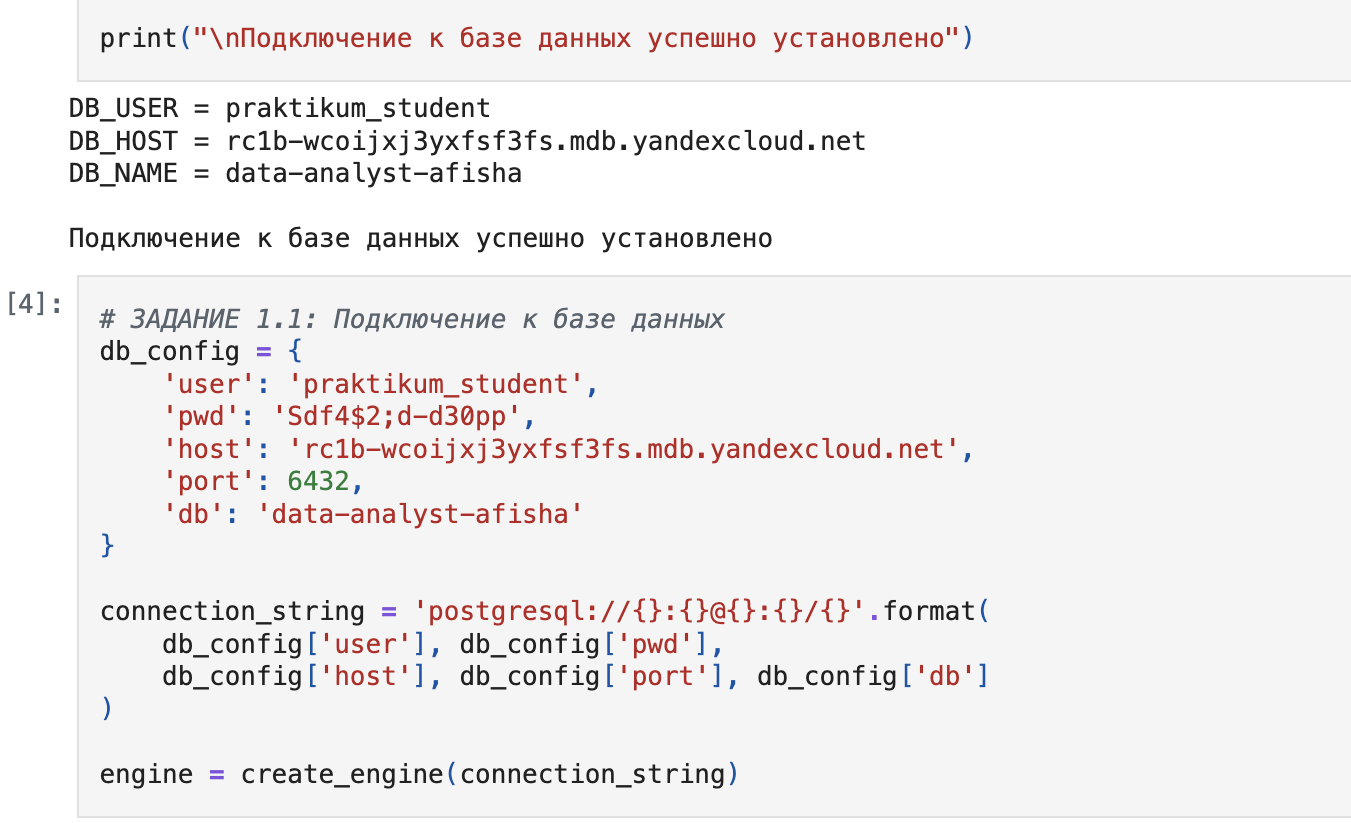
    

</div>




 <div class="alert alert-block alert-danger">
    
<b>Ошибка[2]:</b>  Недочет не исправлен, чувствительных данных (пароли и т.п.) на гитхабе быть не должно
    

</div>
